# Evaluating Sternberg Rate Models

For well-trained multiload models, let's see if we can find a pattern to the trials that are incorrect

In [ ]:
import os, scipy.io 
import numpy as np 
import matplotlib.pyplot as plt 
import pickle as pk

import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate/')
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis')

import model
import generate_rate_data_multiload as grdm
import rate_neuron_utils as rn
import load_data as ld

2026-06-09 14:56:39.449987: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-09 14:56:39.458050: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-09 14:56:39.466756: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-09 14:56:39.469387: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-09 14:56:39.476604: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# the models with > 0.7 accuracy are:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/multiload_1_2_3'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_06_03_014901.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_03_034721.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_031000.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_041152.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_180002.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_06_233744.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_023239.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_043128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063128.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_063647.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_06_07_153131.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

## load data

### start with one model

In [ ]:
model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
# neural data
_, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                            all_models_dir = all_models_dir, load_LFP=False)
_, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                            all_models_dir = all_models_dir, load_LFP=False)
# concatenate
rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)
print(rates_data.shape)

trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_match",
                                                    all_models_dir=all_models_dir)
trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    other_labels="balance_stim",
                                                    all_models_dir=all_models_dir)
trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)
trial_perfs = np.concatenate((trial_perfs_match, trial_perfs_stim), axis=0)
trial_labels[np.isinf(trial_labels)] = np.nan # change all inf's to nans for easier processing

settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                      other_labels="balance_stim",
                                      all_models_dir=all_models_dir)

stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
maint_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz'))['stim1_tuning']
load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                other_labels = "balance_stims",
                                all_models_dir=all_models_dir)
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)


(780, 1000, 450)
Loading behavioral data...


In [ ]:
load_labels = trial_labels[:, 0]
loads = np.unique(load_labels)  # [1, 2, 3]

trial_types, trial_idxs = np.unique(trial_labels[:,:2], axis=0, return_inverse=True) # load and match/mismatch

trial_stims = trial_labels[:, 2:6] # stims 1, 2, 3, and probe
unique_stims = np.unique(trial_stims) # 0, 1, 2, 3
print(unique_stims)

[ 0.  1.  2.  3. nan]


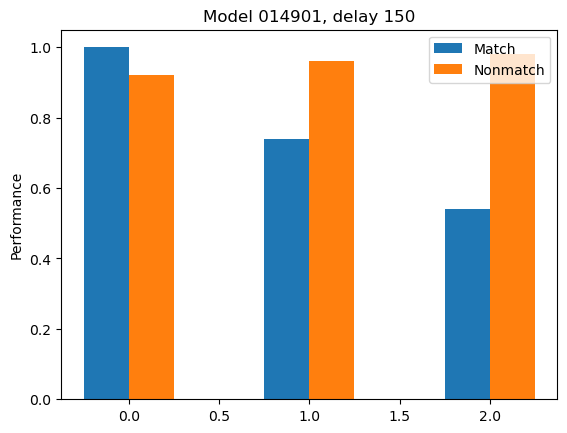

In [19]:
# better at match/mismatch based on load?

match_perfs = []
nonmatch_perfs = []
for load in loads:
    perf_match = trial_perfs_match[(trial_labels_match[:,0] == load) & (trial_labels_match[:,1] == 1)]
    perf_nonmatch = trial_perfs_match[(trial_labels_match[:,0] == load) & (trial_labels_match[:,1] == -1)]
    match_perfs.append(np.mean(perf_match))
    nonmatch_perfs.append(np.mean(perf_nonmatch))

# bar plot of match vs nonmatch performance for each load, side by side
plt.bar(np.arange(len(loads)) - 0.125, match_perfs, width=0.25, label='Match')
plt.bar(np.arange(len(loads)) + 0.125, nonmatch_perfs, width=0.25, label='Nonmatch')
plt.ylabel('Performance')
plt.title(f'Model {model_name[-6:]}, delay {delay}')
plt.legend()
plt.show()


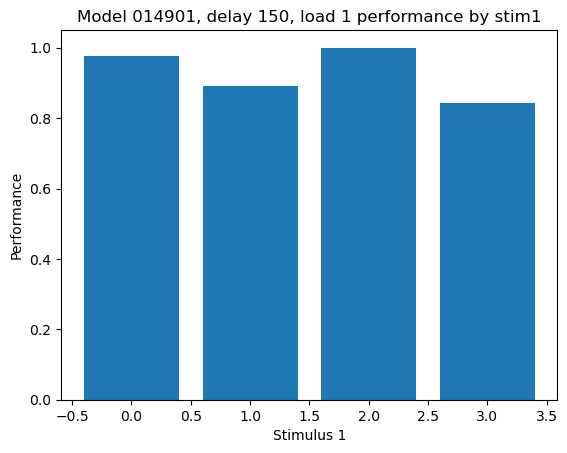

In [ ]:
# look at load 1: is there better performance for a particular stim?

perfs = []
for stim in unique_stims:
    trial_idxs = np.where((load_labels == 1) & (trial_stims[:,0] == stim))[0]
    perfs.append(np.mean(trial_perfs[trial_idxs]))
    
plt.bar(unique_stims, perfs)
plt.xlabel('Stimulus 1')
plt.ylabel('Performance')
plt.title(f'Model {model_name[-6:]}, delay {delay}, load 1 performance by stim1')
plt.show()

In [ ]:
# look at load 1: is there better performance for a particular stim combo?

from itertools import permutations

trial_stims = [0, 2, 3]
trial_stim_patterns = list(permutations(trial_stims))

fig, axs = plt.subplots(1, len(loads), figsize=(4*len(loads), 4), sharey=True)
for i, load in enumerate(loads):
    unique_stims = 
    perfs = []
    for stim in unique_stims:
        trial_idxs = np.where((load_labels == 1) & (trial_stims[:,0] == stim))[0]
        perfs.append(np.mean(trial_perfs[trial_idxs]))
        
    axs[i].bar(unique_stims, perfs)
    axs[i].set_xlabel('Stimulus 1')
    axs[i].set_ylabel('Performance')
    axs[i].set_title(f'Load {load}')
plt.suptitle(f'Model {model_name[-6:]}, delay {delay}, load 1 performance by stim1')
plt.show()

### all models

Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...
Loading behavioral data...


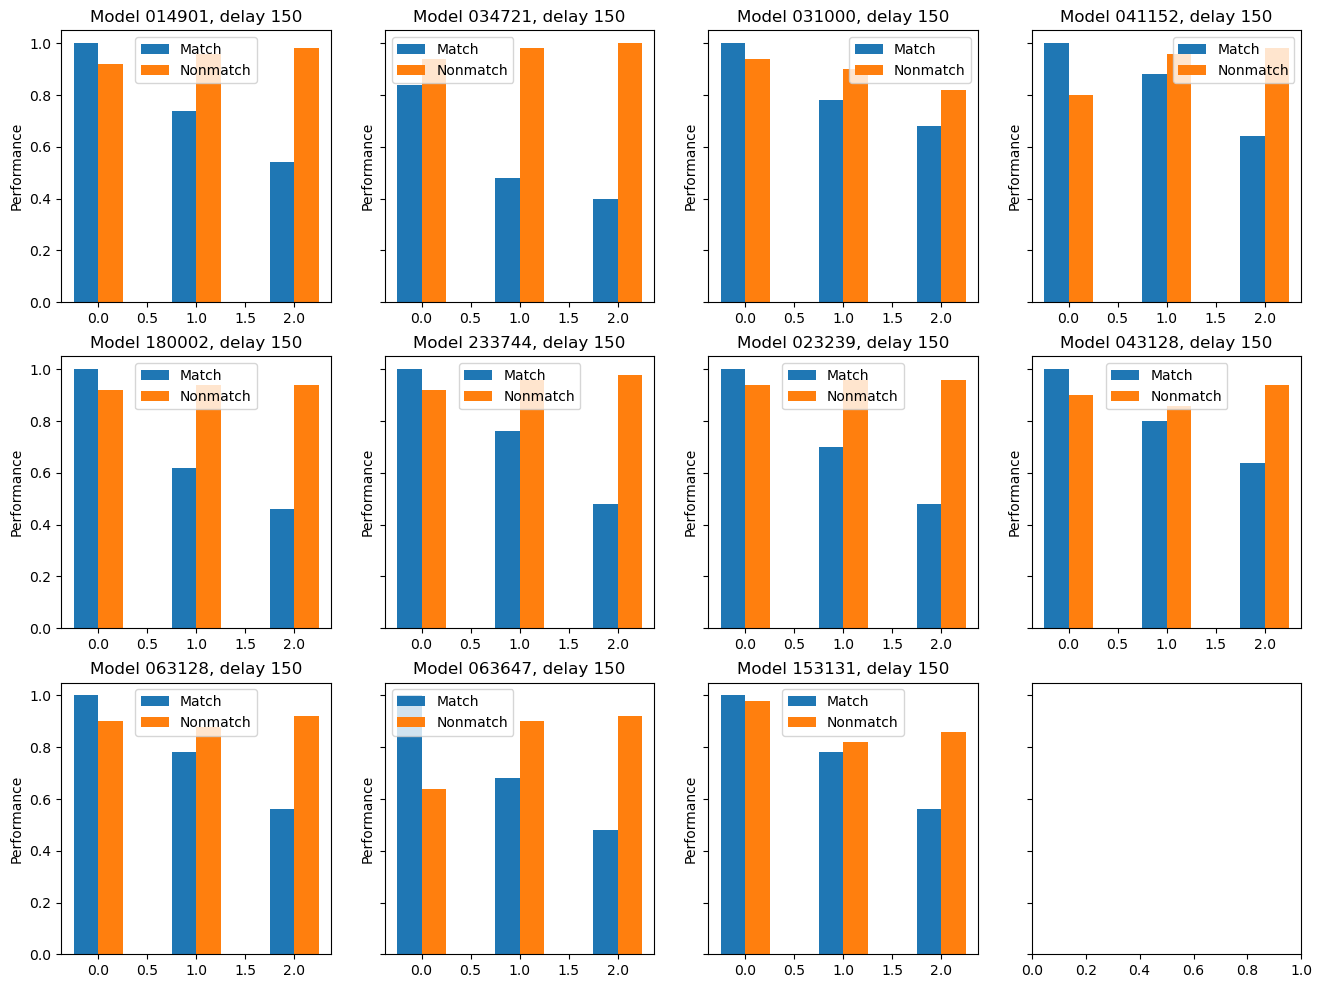

In [20]:
fig, axs = plt.subplots(3, 4, figsize=(16, 12), sharey=True)
axs = axs.flatten()
for i, model_name in enumerate(model_names):
    model_dir = os.path.join(all_models_dir, model_name)

    # find files for this delay of interest
    data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
    # neural data
    _, rates_data_match = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_match",
                                                all_models_dir = all_models_dir, load_LFP=False)
    _, rates_data_stim = ld.load_neural_rate_data(model_name, condn_phrase, condn_num, other_labels= "balance_stim",
                                                all_models_dir = all_models_dir, load_LFP=False)
    # concatenate
    rates_data = np.concatenate((rates_data_match, rates_data_stim), axis=0)

    trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels="balance_match",
                                                        all_models_dir=all_models_dir)
    trial_labels_stim, trial_perfs_stim, trial_outputs_stim = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels="balance_stim",
                                                        all_models_dir=all_models_dir)
    trial_labels = np.concatenate((trial_labels_match, trial_labels_stim), axis=0)
    trial_perfs = np.concatenate((trial_perfs_match, trial_perfs_stim), axis=0)
    trial_labels[np.isinf(trial_labels)] = np.nan # change all inf's to nans for easier processing

    settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                        other_labels="balance_stim",
                                        all_models_dir=all_models_dir)

    stim1_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_nonparametric.npz'))['stim1_tuning']
    maint_stimtuning = np.load(os.path.join(model_dir, 'stim1_tuning_duringdelay_nonparametric.npz'))['stim1_tuning']
    load_tuning = rn.calc_load_tuning_multiload(model_name, condn_phrase, condn_num, 
                                    other_labels = "balance_stims",
                                    all_models_dir=all_models_dir)
    exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
    
    load_labels = trial_labels[:, 0]
    loads = np.unique(load_labels)  # [1, 2, 3]

    trial_types, trial_idxs = np.unique(trial_labels[:,:2], axis=0, return_inverse=True) # load and match/mismatch

    trial_stims = trial_labels[:, 2:6] # stims 1, 2, 3, and probe
    unique_stims = np.unique(trial_stims) # 0, 1, 2, 3

    match_perfs = []
    nonmatch_perfs = []
    for load in loads:
        perf_match = trial_perfs_match[(trial_labels_match[:,0] == load) & (trial_labels_match[:,1] == 1)]
        perf_nonmatch = trial_perfs_match[(trial_labels_match[:,0] == load) & (trial_labels_match[:,1] == -1)]
        match_perfs.append(np.mean(perf_match))
        nonmatch_perfs.append(np.mean(perf_nonmatch))

    # bar plot of match vs nonmatch performance for each load, side by side
    axs[i].bar(np.arange(len(loads)) - 0.125, match_perfs, width=0.25, label='Match')
    axs[i].bar(np.arange(len(loads)) + 0.125, nonmatch_perfs, width=0.25, label='Nonmatch')
    axs[i].set_ylabel('Performance')
    axs[i].set_title(f'Model {model_name[-6:]}, delay {delay}')
    axs[i].legend()
plt.show()



In [21]:
# make a boxplot across models

performance_byload = {}
for i, model_name in enumerate(model_names):
    model_dir = os.path.join(all_models_dir, model_name)

    # find files for this delay of interest
    data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])

    trial_labels_match, trial_perfs_match, trial_outputs_match = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                        other_labels="balance_match",
                                                        all_models_dir=all_models_dir)
    
    trial_labels[np.isinf(trial_labels)] = np.nan # change all inf's to nans for easier processing

    settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num,
                                        other_labels="balance_stim",
                                        all_models_dir=all_models_dir)

    load_labels = trial_labels[:, 0]
    loads = np.unique(load_labels)  # [1, 2, 3]

    trial_types, trial_idxs = np.unique(trial_labels[:,:2], axis=0, return_inverse=True) # load and match/mismatch

    trial_stims = trial_labels[:, 2:6] # stims 1, 2, 3, and probe
    unique_stims = np.unique(trial_stims) # 0, 1, 2, 3

    match_perfs = []
    nonmatch_perfs = []
    for load in loads:
        for match in [1, -1]:
            perf = trial_perfs_match[(trial_labels_match[:,0] == load) & (trial_labels_match[:,1] == match)]
            key = (load, match)
            if key not in performance_byload:
                performance_byload[key] = []
            performance_byload[key].append(np.mean(perf))


/tmp/ipykernel_340869/4053650927.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


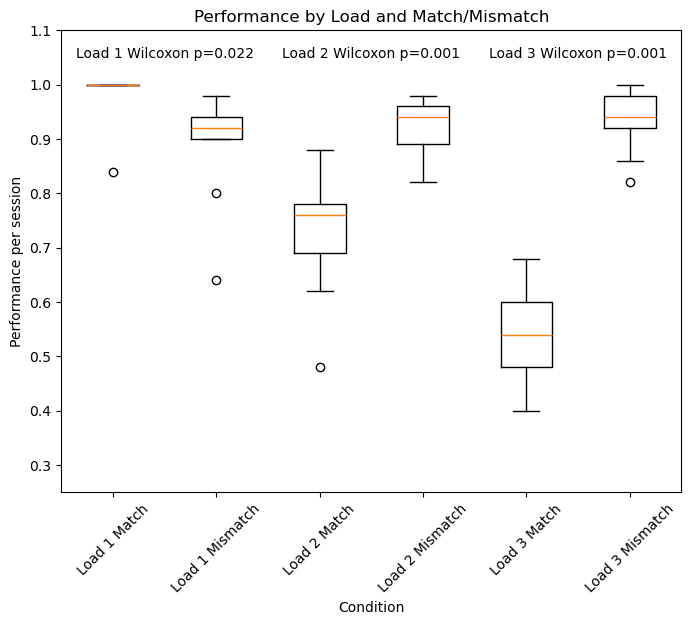

In [26]:
# plot performance by load and match/mismatch
labels = ['Load 1 Match', 'Load 1 Mismatch', 'Load 2 Match', 'Load 2 Mismatch', 'Load 3 Match', 'Load 3 Mismatch']
data_to_plot = [performance_byload[(1, 1)], performance_byload[(1, -1)], performance_byload[(2, 1)], performance_byload[(2, -1)], performance_byload[(3, 1)], performance_byload[(3, -1)]]
plt.figure(figsize=(8,6))
plt.boxplot(data_to_plot, labels=labels)

# # plot gray lines for each session
# for i in range(len(performance_byload[(1, 1)])):
#     plt.plot([1, 2, 3, 4], [performance_byload[(1, 1)][i], performance_byload[(1, -1)][i], performance_byload[(2, 1)][i], performance_byload[(2, -1)][i]], color='gray', alpha=0.5)

# check stats, wilcoxon for match vs mismatch at each load
from scipy.stats import wilcoxon
stat1, p_value1 = wilcoxon(performance_byload[(1, 1)], performance_byload[(1, -1)])
stat2, p_value2 = wilcoxon(performance_byload[(2, 1)], performance_byload[(2, -1)])
stat3, p_value3 = wilcoxon(performance_byload[(3, 1)], performance_byload[(3, -1)])

# plot on the graph
plt.text(1.5, 1.05, f'Load 1 Wilcoxon p={p_value1:.3f}', ha='center')
plt.text(3.5, 1.05, f'Load 2 Wilcoxon p={p_value2:.3f}', ha='center')
plt.text(5.5, 1.05, f'Load 3 Wilcoxon p={p_value3:.3f}', ha='center')
plt.ylim(0.25, 1.1)
plt.xlabel('Condition')

plt.ylabel('Performance per session')
plt.title('Performance by Load and Match/Mismatch')
plt.xticks(rotation=45)
plt.show()